In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Esercizio 8

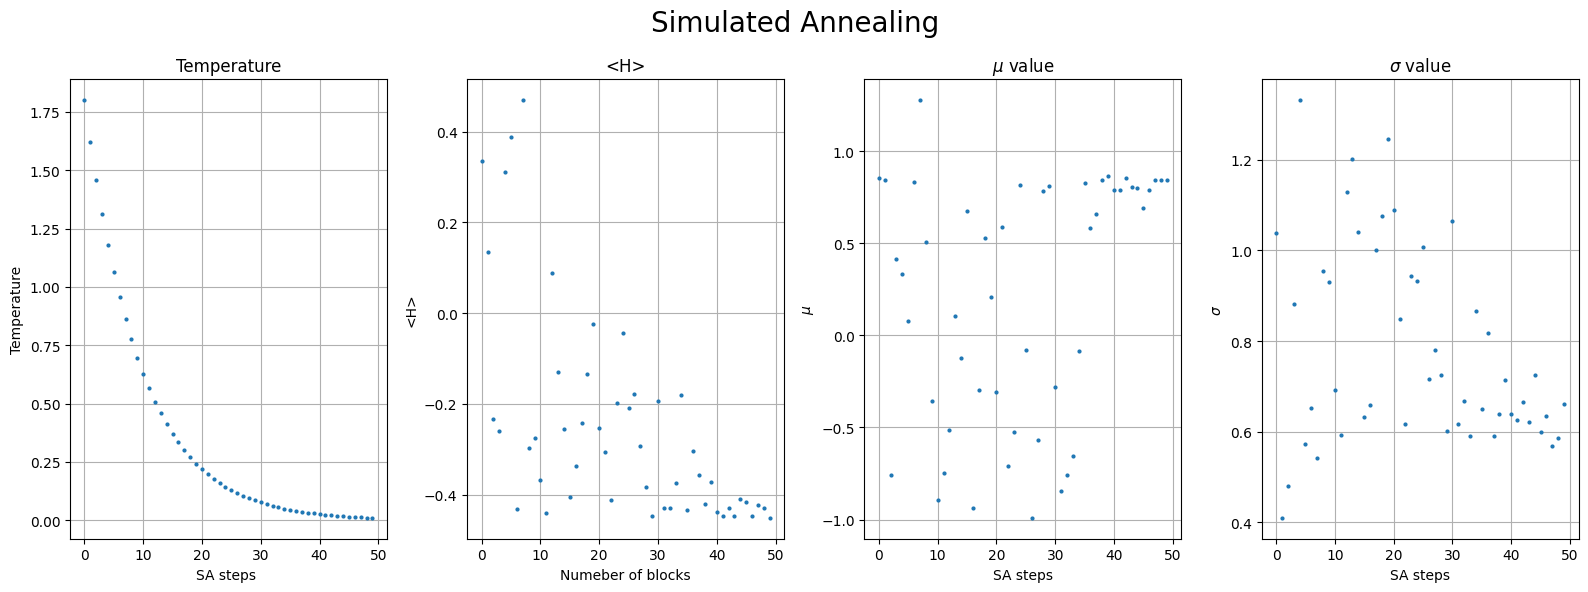

sigma = 0.660714

mu = 0.845167

<H> = -0.451368 +/- 0.007708



In [51]:

T, H, H_err, mu, sigma = np.loadtxt('Dati.dat', unpack=True)
x= np.arange(len(T))

fig, (ax1, ax2, ax3, ax4)= plt.subplots(1, 4, figsize=(16, 6))

fig.suptitle("Simulated Annealing", fontsize= 20)

ax1.plot(x, T, 'o', markersize=2)
ax1.grid(True)
ax1.set_title("Temperature")
ax1.set_xlabel("SA steps ")
ax1.set_ylabel("Temperature")

ax2.errorbar(x, H, fmt ='o', markersize = 2 , elinewidth=0.4)
ax2.grid(True)
ax2.set_title("<H>")
ax2.set_xlabel("Numeber of blocks")
ax2.set_ylabel("<H>")


ax3.plot(x, mu, 'o', markersize = 2)
ax3.set_title("$\mu$ value")
ax3.set_xlabel("SA steps")
ax3.set_ylabel("$\mu$")
ax3.grid(True)

ax4.plot(x, sigma, 'o', markersize = 2)
ax4.set_title("$\sigma$ value")
ax4.set_xlabel("SA steps")
ax4.set_ylabel("$\sigma$")
ax4.grid(True)

plt.tight_layout()
plt.show()

print(f"sigma = {sigma[-1]}\n")
print(f"mu = {mu[-1]}\n")
print(f"<H> = {H[-1]} +/- {H_err[-1]}\n")

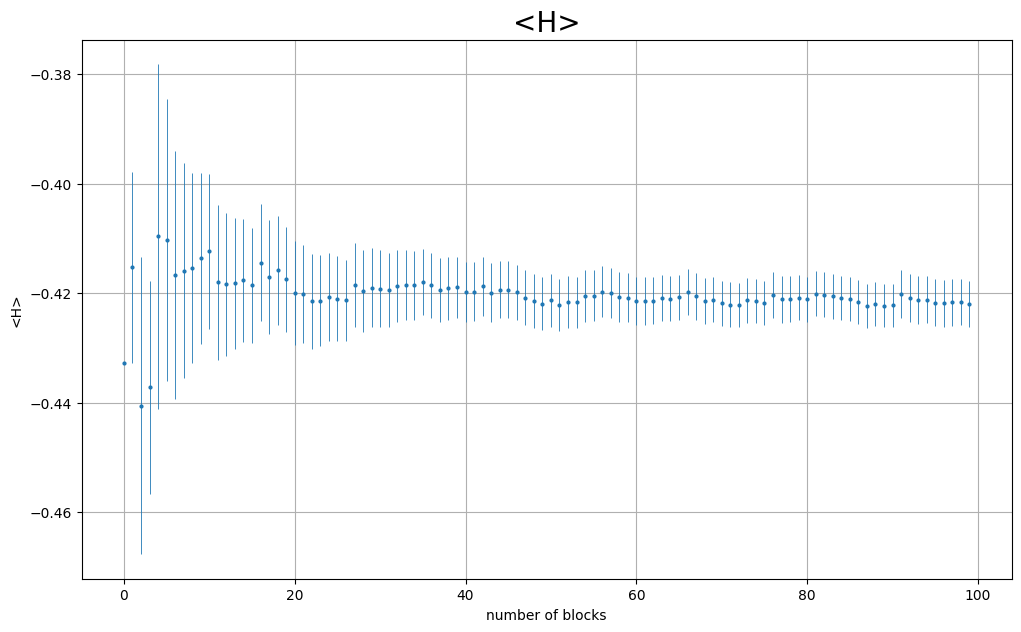

In [46]:
H1, H1_err = np.loadtxt("H.dat", unpack= True)
x=np.arange(len(H1))

plt.figure(figsize=(12, 7))
plt.errorbar(x, H1, H1_err, fmt='o', markersize=2, elinewidth= 0.6)
plt.ylabel("<H>")
plt.xlabel("number of blocks")
plt.title("<H>", fontsize= 20)
plt.grid(True)

L'energia del ground state ottenuta dall'algoritmo si avvicina al valore teorico E=-0.46 .

In [47]:
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

Ground state energy:  -0.46046587969271563
1st excited state energy:  0.09742471331760998
2nd excited state energy:  1.971733134393021


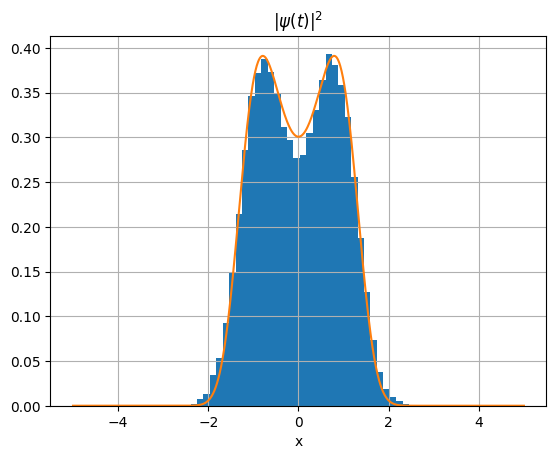

In [48]:
psi_m= np.loadtxt("posizioni.dat")

plt.hist(psi_m, 40, density= True)
plt.plot(x,(psi[0])**2)
plt.grid(True)
plt.xlabel("x")
plt.title("$|\psi(t)|^2$")

plt.show()


Vediamo che la distribuzione di probabilità corrisponde a quella ottenuta dalla funzione d'onda teorica